In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("..") / "data" / "set A corporate_rating.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [5]:
def group_rating(rating):
    if rating in ["AAA", "AA", "A"]:
        return "Investment-High"
    elif rating == "BBB":
        return "Investment-Low"
    elif rating in ["BB", "B"]:
        return "Speculative"
    elif rating in ["CCC", "CC", "C", "D"]:
        return "Distressed"
    else:
        return "Unknown"

df["Risk_Category"] = df["Rating"].apply(group_rating)

df["Risk_Category"].value_counts()

Risk_Category
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64

In [6]:
# Figure 4.2.2.1

# Define the financial metric groups and their corresponding metrics

metric_groups = {
    "Liquidity": ["currentRatio", "quickRatio", "cashRatio"],
    "Profitability": [
        "netProfitMargin", "pretaxProfitMargin", "grossProfitMargin",
        "operatingProfitMargin", "returnOnAssets", "returnOnCapitalEmployed",
        "returnOnEquity"
    ],
    "Efficiency": ["assetTurnover", "fixedAssetTurnover", "payablesTurnover"],
    "Leverage": ["debtEquityRatio", "debtRatio", "companyEquityMultiplier"],
    "Cash Flow": [
        "freeCashFlowOperatingCashFlowRatio", "freeCashFlowPerShare",
        "cashPerShare", "operatingCashFlowPerShare",
        "operatingCashFlowSalesRatio"
    ],
    "Valuation / Other": [
        "effectiveTaxRate", "ebitPerRevenue", "enterpriseValueMultiple",
        "daysOfSalesOutstanding"
    ]
}

# Count the number of metrics in each group
group_counts = {group: len(cols) for group, cols in metric_groups.items()}

# Plot the number of financial metrics by category
plt.figure(figsize=(9, 5))
plt.bar(group_counts.keys(), group_counts.values())
plt.title("Number of Financial Metrics by Category")
plt.xlabel("Financial Metric Category")
plt.ylabel("Number of Metrics")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

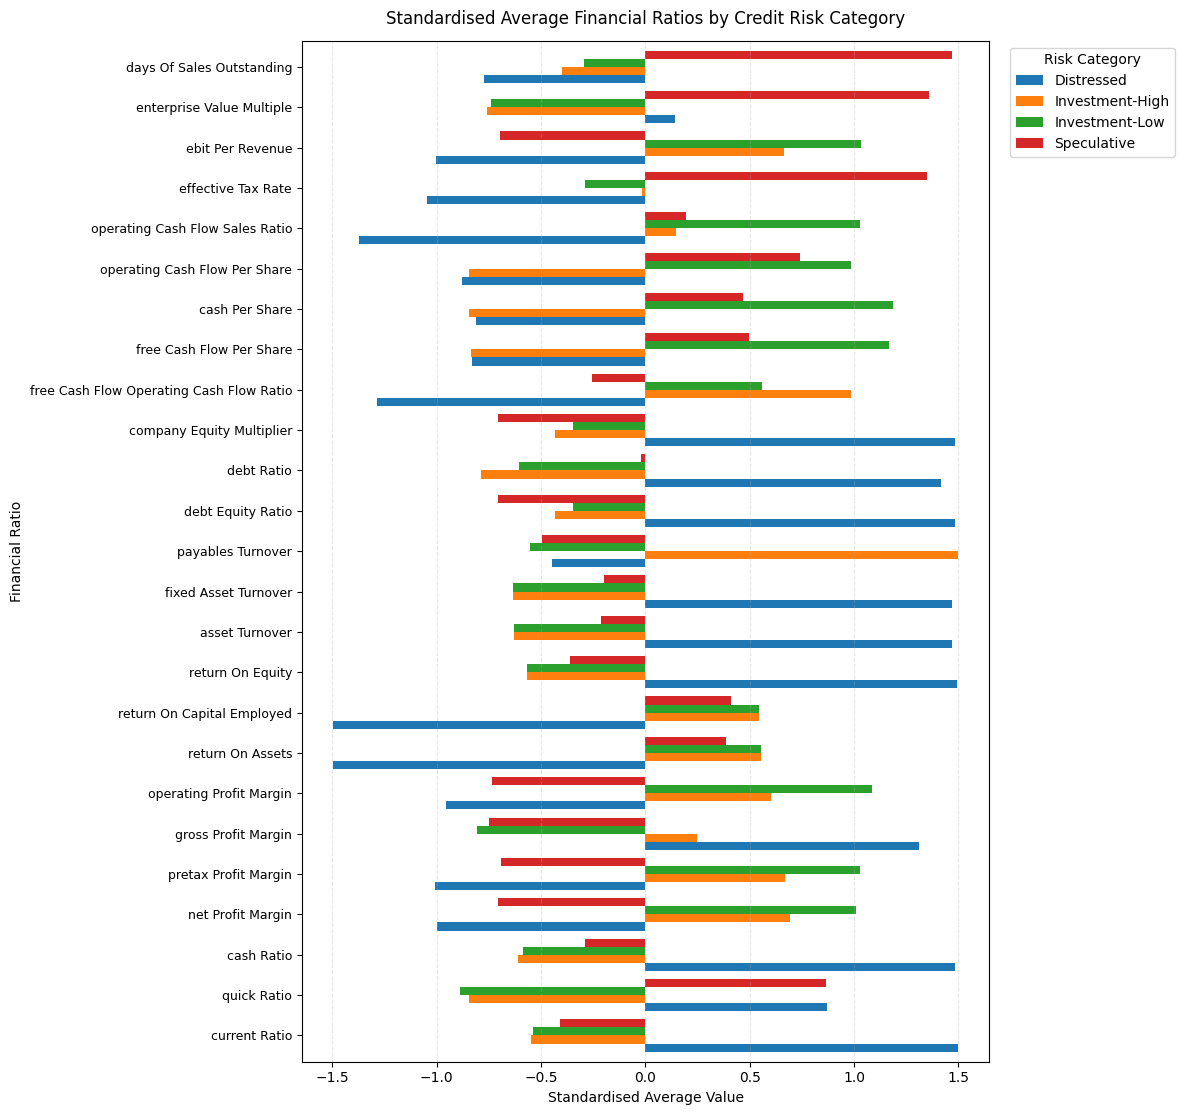

In [ ]:
# Figure 4.2.2.2

# Average financial ratios by credit risk category using standardised values

available_metrics = [
    col
    for cols in metric_groups.values()
    for col in cols
    if col in df.columns
]

# Calculate average value of each financial ratio by risk category
risk_metric_mean = df.groupby("Risk_Category")[available_metrics].mean()

# Standardise each financial ratio so different scales can be compared fairly
plot_data = risk_metric_mean.copy()

plot_data = (plot_data - plot_data.mean()) / plot_data.std()

# Transpose for horizontal bar chart
plot_data = plot_data.T

# Clean feature names for graph labels
plot_data.index = (
    plot_data.index
    .str.replace(r"([a-z])([A-Z])", r"\1 \2", regex=True)
    .str.replace(" / ", "/")
)

# Plot graph
ax = plot_data.plot(
    kind="barh",
    figsize=(12, max(8, 0.45 * len(plot_data))),
    width=0.8
)

ax.set_title("Standardised Average Financial Ratios by Credit Risk Category", pad=12)
ax.set_xlabel("Standardised Average Value")
ax.set_ylabel("Financial Ratio")
ax.tick_params(axis="y", labelsize=9)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(title="Risk Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

Metrics used for boxplot:
['currentRatio', 'quickRatio', 'cashRatio', 'netProfitMargin', 'returnOnAssets', 'returnOnEquity', 'debtRatio', 'debtEquityRatio', 'assetTurnover', 'operatingCashFlowSalesRatio']


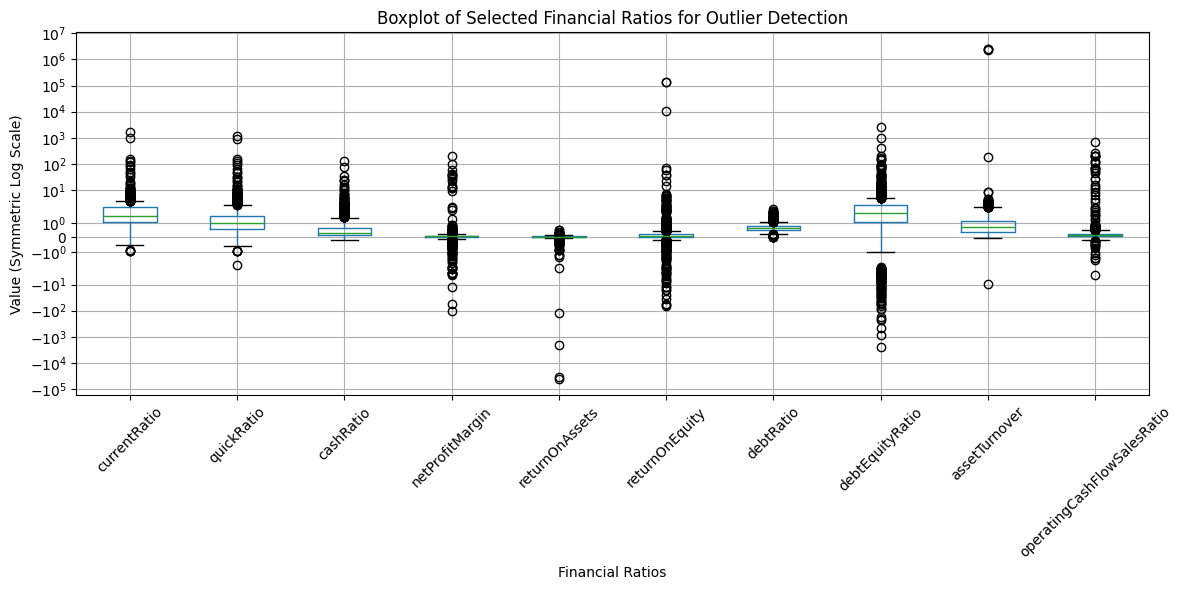

In [ ]:
# Figure 4.2.3.1

# Boxplot of selected financial ratios for outlier detection
selected_metrics = [
    "currentRatio",
    "quickRatio",
    "cashRatio",
    "netProfitMargin",
    "returnOnAssets",
    "returnOnEquity",
    "debtRatio",
    "debtEquityRatio",
    "assetTurnover",
    "operatingCashFlowSalesRatio"
]

available_metrics = [col for col in selected_metrics if col in df.columns]

print("Metrics used for boxplot:")
print(available_metrics)

plt.figure(figsize=(12, 6))

df[available_metrics].boxplot()

plt.yscale("symlog")

plt.title("Boxplot of Selected Financial Ratios for Outlier Detection")
plt.xlabel("Financial Ratios")
plt.ylabel("Value (Symmetric Log Scale)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# Data quality assessment: missing values and duplicates

print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nNumber of duplicated rows:", df.duplicated().sum())

Missing values per column:
Series([], dtype: int64)

Total missing values: 0

Number of duplicated rows: 0


In [7]:
# Table 4.2.3.2
# IQR-Based Outlier Count for Selected Financial Ratios


selected_metrics = [
    "currentRatio",
    "quickRatio",
    "cashRatio",
    "netProfitMargin",
    "returnOnAssets",
    "returnOnEquity",
    "debtRatio",
    "debtEquityRatio",
    "assetTurnover",
    "operatingCashFlowSalesRatio"
]

available_metrics = [col for col in selected_metrics if col in df.columns]

outlier_summary = []

for col in available_metrics:
    # Convert column to numeric to avoid errors
    numeric_col = pd.to_numeric(df[col], errors="coerce")
    
    Q1 = numeric_col.quantile(0.25)
    Q3 = numeric_col.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((numeric_col < lower_bound) | (numeric_col > upper_bound)).sum()
    
    outlier_summary.append({
        "Financial Ratio": col,
        "Lower Bound": round(lower_bound, 4),
        "Upper Bound": round(upper_bound, 4),
        "Outlier Count": int(outlier_count)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)

,Financial Ratio,Lower Bound,Upper Bound,Outlier Count
0,currentRatio,-0.5705,3.8093,132
1,quickRatio,-0.6737,2.7303,168
2,cashRatio,-0.6108,1.3663,141
3,netProfitMargin,-0.1197,0.2555,232
4,returnOnAssets,-0.0683,0.1649,167
5,returnOnEquity,-0.1768,0.4287,315
6,debtRatio,0.2141,1.0713,88
7,debtEquityRatio,-1.3410,5.0206,283
8,assetTurnover,-0.6762,2.1597,108
9,operatingCashFlowSalesRatio,-0.1766,0.4914,156
